In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf
from fredapi import Fred
import sqlite3
import statsmodels.api as sm

plt.style.use('seaborn-v0_8')


In [ ]:
# Download S&P 500 monthly data
sp500 = yf.download("^GSPC", start="2015-01-01", end="2025-01-01", interval="1mo")
sp500 = sp500[['Close']].copy()
sp500.columns = ['SP500']
sp500['SP500_Return'] = sp500['SP500'].pct_change() * 100
sp500 = sp500.dropna()
print(sp500.head())

[*********************100%***********************]  1 of 1 completed

                  SP500  SP500_Return
Date                                 
2015-02-01  2104.500000      5.489251
2015-03-01  2067.889893     -1.739611
2015-04-01  2085.510010      0.852082
2015-05-01  2107.389893      1.049138
2015-06-01  2063.110107     -2.101167


In [3]:
print(len(sp500))

119


In [4]:
import ssl
ssl._create_default_https_context = ssl._create_unverified_context

fred = Fred(api_key='b06a7105aae59d573de5443caafb23b8')

fed_funds = fred.get_series('FEDFUNDS', observation_start='2015-01-01', observation_end='2025-01-01')
unemployment = fred.get_series('UNRATE', observation_start='2015-01-01', observation_end='2025-01-01')
cpi = fred.get_series('CPIAUCSL', observation_start='2015-01-01', observation_end='2025-01-01')

fed_funds = pd.DataFrame(fed_funds, columns=['FedFunds'])
unemployment = pd.DataFrame(unemployment, columns=['Unemployment'])
cpi = pd.DataFrame(cpi, columns=['CPI'])
cpi['Inflation'] = cpi['CPI'].pct_change() * 100

print("FRED data loaded.")

FRED data loaded.


In [5]:
# Create a local SQL database file
conn = sqlite3.connect('macro_data.db')

# Write each dataset to a SQL table
sp500.to_sql('sp500', conn, if_exists='replace')
fed_funds.to_sql('fed_funds', conn, if_exists='replace')
unemployment.to_sql('unemployment', conn, if_exists='replace')
cpi.to_sql('cpi', conn, if_exists='replace')

print("Data saved to SQL database.")

Data saved to SQL database.


In [11]:
query = """
SELECT 
    s.Date,
    s.SP500_Return,
    f.FedFunds,
    u.Unemployment,
    c.Inflation
FROM sp500 s
JOIN fed_funds f ON s.Date = f.[index]
JOIN unemployment u ON s.Date = u.[index]
JOIN cpi c ON s.Date = c.[index]
ORDER BY s.Date
"""

df = pd.read_sql_query(query, conn)
df['Date'] = pd.to_datetime(df['Date'])
df = df.dropna()
print(f"Combined dataset: {len(df)} monthly observations")
print(df.head())

Combined dataset: 119 monthly observations
        Date  SP500_Return  FedFunds  Unemployment  Inflation
0 2015-02-01      5.489251      0.11           5.5   0.253464
1 2015-03-01     -1.739611      0.11           5.4   0.269395
2 2015-04-01      0.852082      0.12           5.4   0.104248
3 2015-05-01      1.049138      0.12           5.6   0.329775
4 2015-06-01     -2.101167      0.13           5.3   0.276792


In [12]:
# Summary statistics
print("=== Summary Statistics ===")
print(df.describe().round(3))

# Correlation matrix
print("\n=== Correlation Matrix ===")
print(df[['SP500_Return','FedFunds','Unemployment','Inflation']].corr().round(3))

=== Summary Statistics ===
                             Date  SP500_Return  FedFunds  Unemployment  \
count                         119       119.000   119.000       119.000   
mean   2019-12-31 15:55:57.983193         1.010     1.797         4.674   
min           2015-02-01 00:00:00       -12.512     0.050         3.400   
25%           2017-07-16 12:00:00        -1.746     0.130         3.700   
50%           2020-01-01 00:00:00         1.590     1.160         4.100   
75%           2022-06-16 00:00:00         3.569     2.405         5.000   
max           2024-12-01 00:00:00        12.684     5.330        14.800   
std                           NaN         4.431     1.875         1.738   

       Inflation  
count    119.000  
mean       0.255  
min       -0.792  
25%        0.102  
50%        0.236  
75%        0.377  
max        1.256  
std        0.277  

=== Correlation Matrix ===
              SP500_Return  FedFunds  Unemployment  Inflation
SP500_Return         1.000     0.046

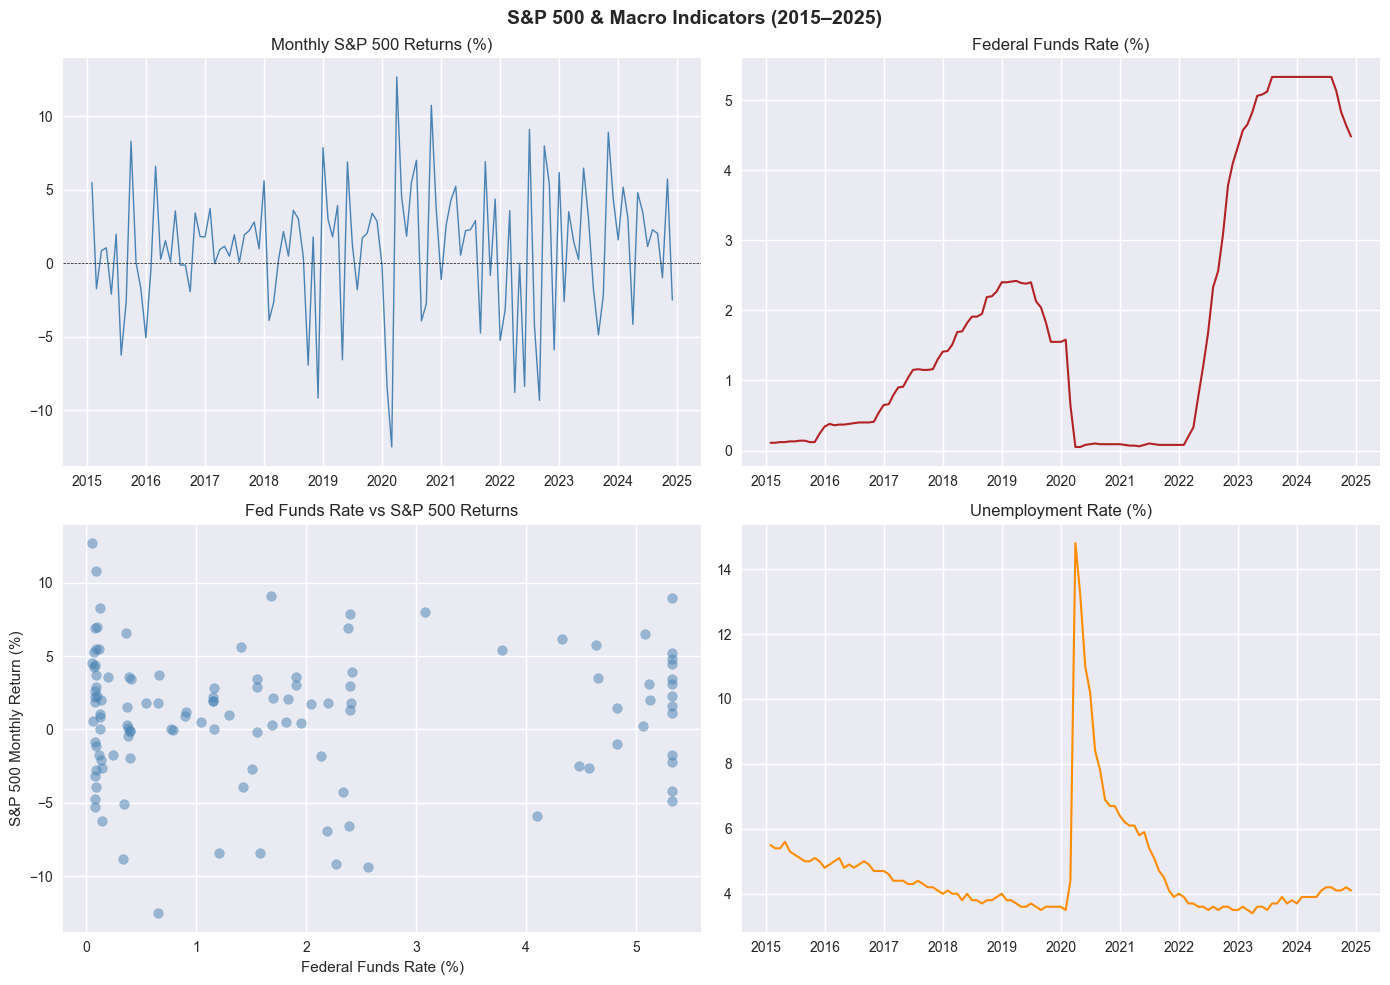

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('S&P 500 & Macro Indicators (2015–2025)', fontsize=14, fontweight='bold')

# S&P 500 returns over time
axes[0,0].plot(df['Date'], df['SP500_Return'], color='steelblue', linewidth=1)
axes[0,0].axhline(0, color='black', linewidth=0.5, linestyle='--')
axes[0,0].set_title('Monthly S&P 500 Returns (%)')

# Fed Funds Rate over time
axes[0,1].plot(df['Date'], df['FedFunds'], color='firebrick', linewidth=1.5)
axes[0,1].set_title('Federal Funds Rate (%)')

# Scatter: Fed Funds vs S&P 500 Returns
axes[1,0].scatter(df['FedFunds'], df['SP500_Return'], alpha=0.5, color='steelblue')
axes[1,0].set_xlabel('Federal Funds Rate (%)')
axes[1,0].set_ylabel('S&P 500 Monthly Return (%)')
axes[1,0].set_title('Fed Funds Rate vs S&P 500 Returns')

# Unemployment over time
axes[1,1].plot(df['Date'], df['Unemployment'], color='darkorange', linewidth=1.5)
axes[1,1].set_title('Unemployment Rate (%)')

plt.tight_layout()
plt.savefig('macro_charts.png', dpi=150, bbox_inches='tight')
plt.show()

In [14]:
# Multiple regression: SP500 Returns ~ Fed Funds + Unemployment + Inflation
X = df[['FedFunds', 'Unemployment', 'Inflation']]
X = sm.add_constant(X)
y = df['SP500_Return']

model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:           SP500_Return   R-squared:                       0.106
Model:                            OLS   Adj. R-squared:                  0.082
Method:                 Least Squares   F-statistic:                     4.536
Date:                Fri, 22 May 2026   Prob (F-statistic):            0.00482
Time:                        09:26:05   Log-Likelihood:                -338.85
No. Observations:                 119   AIC:                             685.7
Df Residuals:                     115   BIC:                             696.8
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const           -4.6837      1.638     -2.860   

In [15]:
high_rate_query = """
SELECT 
    CASE WHEN FedFunds >= 4 THEN 'High Rate (>=4%)' ELSE 'Low Rate (<4%)' END AS rate_regime,
    ROUND(AVG(SP500_Return), 2) AS avg_return,
    ROUND(MIN(SP500_Return), 2) AS worst_month,
    ROUND(MAX(SP500_Return), 2) AS best_month,
    COUNT(*) AS num_months
FROM (
    SELECT s.SP500_Return, f.FedFunds
    FROM sp500 s
    JOIN fed_funds f ON s.Date = f.[index]
)
GROUP BY rate_regime
"""

result = pd.read_sql_query(high_rate_query, conn)
print("=== S&P 500 Performance by Interest Rate Regime ===")
print(result)

conn.close()

=== S&P 500 Performance by Interest Rate Regime ===
        rate_regime  avg_return  worst_month  best_month  num_months
0  High Rate (>=4%)        1.54        -5.90        8.92          25
1    Low Rate (<4%)        0.87       -12.51       12.68          94
